<a href="https://colab.research.google.com/github/DeepthiDaggula/Customer-Segmentation-Project/blob/main/Customer_Segmentation_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install -q kagglehub

import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [7]:
path = kagglehub.dataset_download("kondapuramshivani/mall-customerscsv")

print("Dataset Path:", path)
print("Files:", os.listdir(path))

Using Colab cache for faster access to the 'mall-customerscsv' dataset.
Dataset Path: /kaggle/input/mall-customerscsv
Files: ['Mall_Customers.csv']


In [8]:
df = pd.read_csv(os.path.join(path, "Mall_Customers.csv"))

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [10]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [11]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [12]:
df = df.drop("CustomerID", axis=1)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [13]:
df["Gender"] = df["Gender"].map({
    "Male": 0,
    "Female": 1
})

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


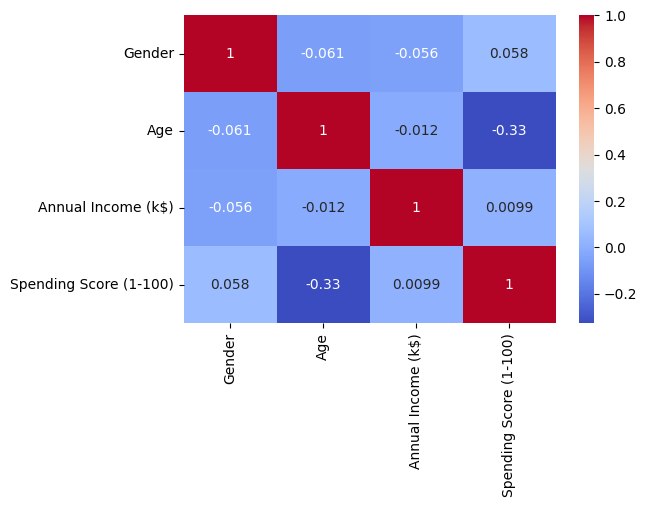

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

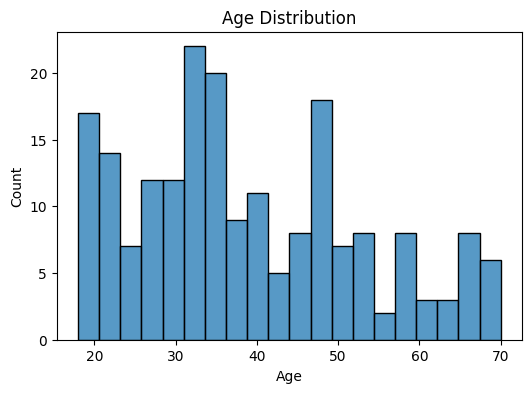

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

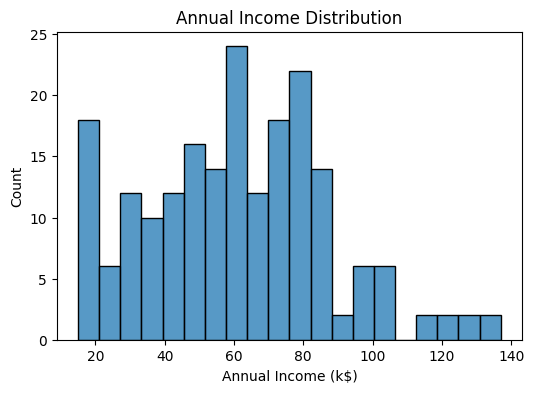

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df["Annual Income (k$)"], bins=20)
plt.title("Annual Income Distribution")
plt.show()

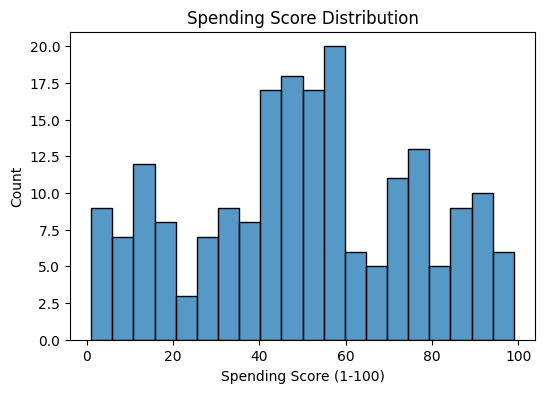

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df["Spending Score (1-100)"], bins=20)
plt.title("Spending Score Distribution")
plt.show()

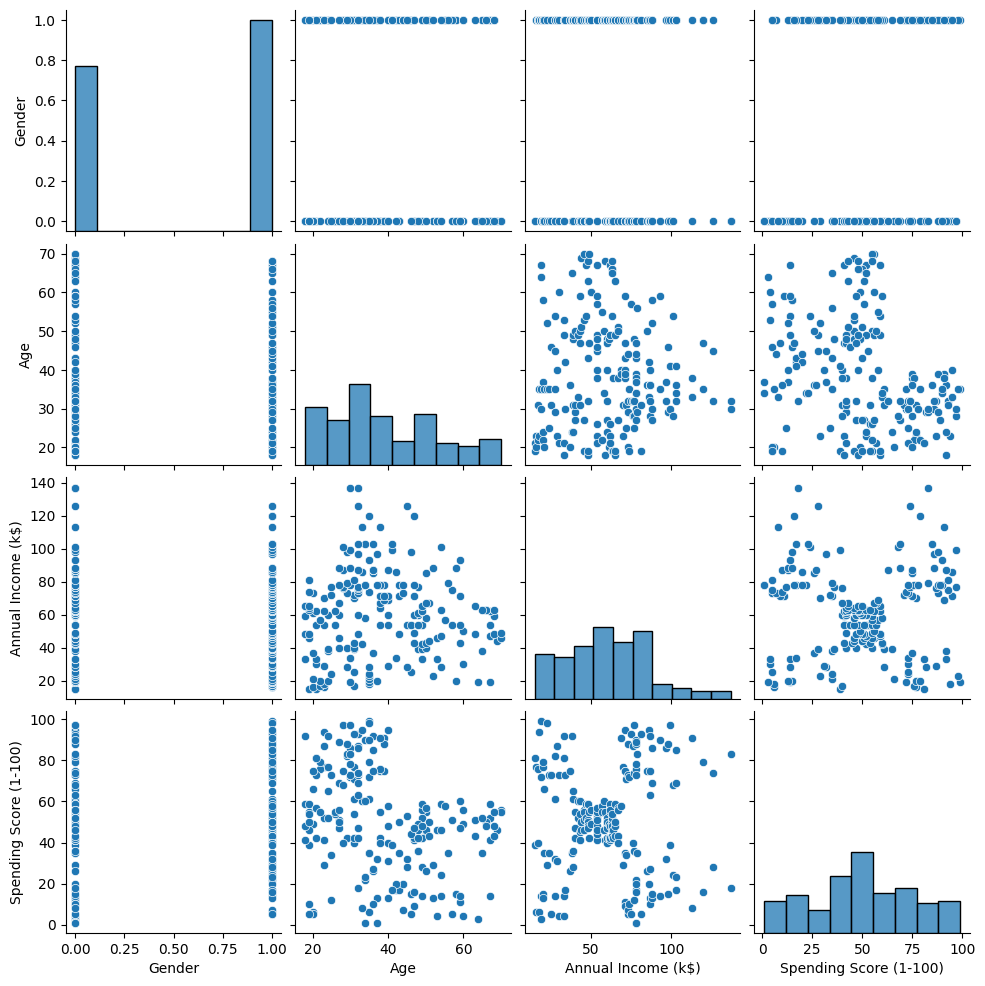

In [18]:
sns.pairplot(df)
plt.show()

In [19]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

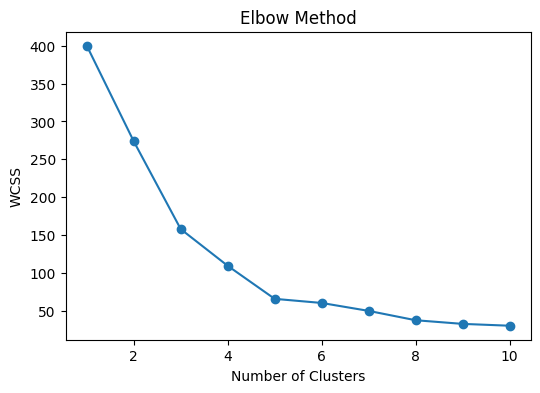

In [21]:
wcss = []

for i in range(1,11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [22]:
kmeans = KMeans(n_clusters=5, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

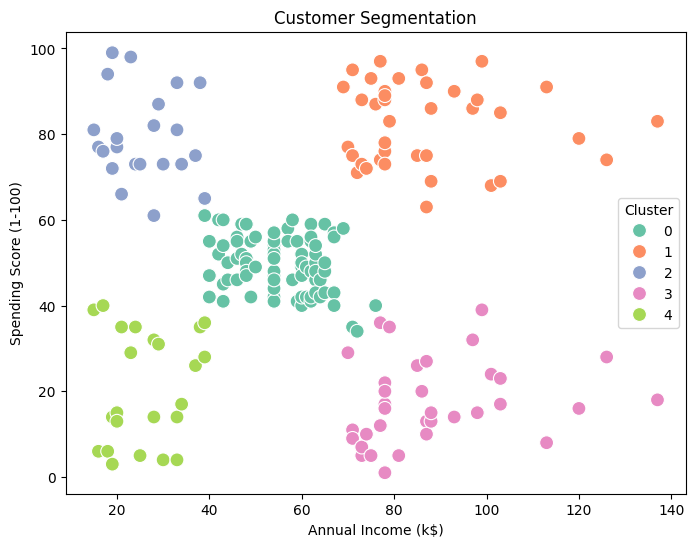

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2",
    data=df,
    s=100
)

plt.title("Customer Segmentation")
plt.show()

In [24]:
df.groupby("Cluster").mean(numeric_only=True)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.592593,42.716049,55.296296,49.518519
1,0.538462,32.692308,86.538462,82.128205
2,0.590909,25.272727,25.727273,79.363636
3,0.457143,41.114286,88.200000,17.114286
4,0.608696,45.217391,26.304348,20.913043


In [25]:
df["Cluster"].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


In [26]:
df.to_csv("Customer_Segmentation_Output.csv", index=False)

print("Project Completed Successfully!")

Project Completed Successfully!
